In [11]:
#### Libraries ###
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc

import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread


import matplotlib.pyplot as plt
import seaborn as sns

os.chdir("/data/scottaa/cta_onco_fetal")

In [ ]:
all_results_cta_genes_tables_dir = "all_results/tables/cta_genes"
dotplot_save_dir = "all_results/figures/cta_genes_2"
os.makedirs(dotplot_save_dir, exist_ok = True)

for gene_expression_file in os.listdir(all_results_cta_genes_tables_dir):
    print(gene_expression_file)
    df = pd.read_csv(os.path.join(all_results_cta_genes_tables_dir, gene_expression_file))
    sample_gene_df = (
        df.groupby(["sample_id", "gene"])
        .apply(lambda x: pd.Series({
            "n_cells": x["n_cells"].sum(),
            "n_positive_cells": x["n_positive_cells"].sum(),
            "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
            "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
        }))
        .reset_index()
    )
    

cell_populations_cta_gene_expression.csv
embryos_mixed_cta_gene_expression.csv
fetal_gonad_cta_gene_expression.csv
hgsoc_subtype_define_cta_gene_expression.csv
hgsoc_tissue_architecture_cta_gene_expression.csv
ovarian_cancer_ccca_cta_gene_expression.csv
subtype_evolution_cta_gene_expression.csv


In [22]:
list(df.sample_id.unique())

['G1_1_Ovary',
 'G2_2_Ovary',
 'G3_1_Testis',
 'G4_2_Testis',
 'G_1_2_M_Mesonephros',
 'G_2_F_Mesonephros',
 'G5_A_2_Ovary',
 'G5_B_2_Ovary',
 'G6_A_Mixed',
 'G6_B_Mixed']

/tmp/ipykernel_2749223/3667181002.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2749223/3667181002.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dotplot_df.groupby(["predicted_cell_type", "gene"])
/tmp/ipykernel_2749223/3667181002.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=Fa

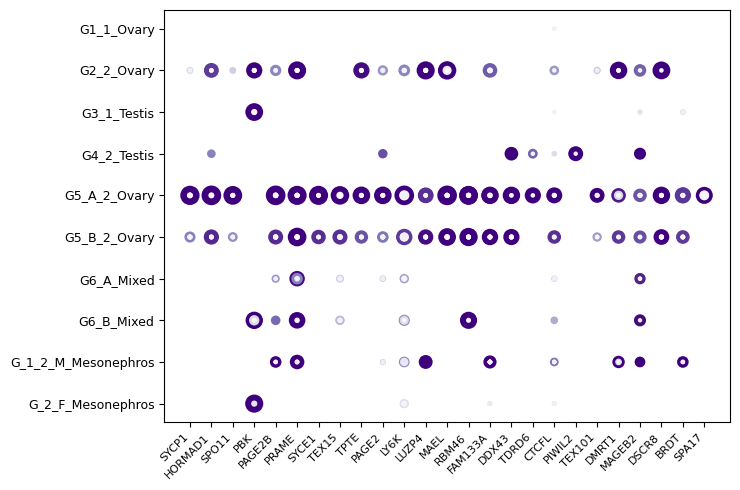

In [ ]:
# Cluster samples - optional but useful
from scipy.cluster.hierarchy import linkage, leaves_list
from matplotlib.colors import PowerNorm

df = pd.read_csv(os.path.join("all_results/tables/cta_genes/fetal_gonad_cta_gene_expression.csv"))

sample_gene_df = (
    df.groupby(["sample_id", "gene", "predicted_cell_type"])
    .apply(lambda x: pd.Series({
        "n_cells": x["n_cells"].sum(),
        "n_positive_cells": x["n_positive_cells"].sum(),
        "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
        "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
    }))
    .reset_index()
)

top_n = 25

gene_order = (
    sample_gene_df.groupby("gene")["mean_expression"]
    .max()
    .sort_values(ascending=False)
    .index
)

gene_order_top = gene_order[:top_n]

dotplot_df = sample_gene_df.copy()
dotplot_df = dotplot_df[dotplot_df["gene"].isin(gene_order_top)]

# remove non-expressing entries (critical)
dotplot_df = dotplot_df[dotplot_df["n_positive_cells"] > 0].copy()

dotplot_df["gene"] = pd.Categorical(
    dotplot_df["gene"],
    categories=gene_order_top,
    ordered=True
)

cluster_input_df = (
    dotplot_df.groupby(["predicted_cell_type", "gene"])
    .apply(lambda x: pd.Series({
        "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
    }))
    .reset_index()
)

# Cluster for matrix - mean expression
cluster_df = (
    cluster_input_df
    .pivot(index="predicted_cell_type", columns="gene", values="mean_expression")
    .fillna(0)
)

X = cluster_df.values
Z = linkage(X, method="average", metric="correlation")
cell_order = cluster_df.index[leaves_list(Z)]

dotplot_df["predicted_cell_type"] = pd.Categorical(
    dotplot_df["predicted_cell_type"],
    categories=cell_order,
    ordered=True
)
sample_order = list(df.sample_id.unique())
min_width = 6
min_height = 4
max_width = 20
max_height = 12

fig_width = min(max(len(gene_order_top) * 0.3, min_width), max_width)
fig_height = min(max(len(sample_order) * 0.5, min_height), max_height)

plt.figure(figsize=(fig_width, fig_height))
sns.scatterplot(
    data=dotplot_df,
    x="gene",
    y="sample_id",
    size="frac_positive_cells",
    hue="mean_expression",
    sizes=(10, 200),
    palette="Purples",
    marker="o",
    linewidth=0,
    edgecolor=None,
    hue_norm=(dotplot_df["mean_expression"].min(), dotplot_df["mean_expression"].quantile(0.95))
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=9)

plt.xlabel("")
plt.ylabel("")
plt.legend([], [], frameon=False)

plt.tight_layout()



In [15]:
sample_gene_df

,sample_id,gene,n_cells,n_positive_cells,frac_positive_cells,mean_expression
0,G1_1_Ovary,CTCFL,1760.0,2.0,0.001136,-2.173568e-02
1,G1_1_Ovary,HSPB9,1760.0,10.0,0.005682,-1.540481e-02
2,G1_1_Ovary,PLAC1,1760.0,425.0,0.241477,8.679925e-17
3,G1_1_Ovary,RGS22,1760.0,22.0,0.012500,-1.031717e-02
4,G1_1_Ovary,TMEFF2,1760.0,51.0,0.028977,-3.258205e-03
...,...,...,...,...,...,...
220,G_2_F_Mesonephros,PAGE4,4775.0,141.0,0.029529,-5.403421e-03
221,G_2_F_Mesonephros,PBK,4775.0,114.0,0.023874,-4.555451e-03
222,G_2_F_Mesonephros,PLAC1,4775.0,13.0,0.002723,-2.176471e-02
223,G_2_F_Mesonephros,PRSS55,4775.0,3.0,0.000628,-1.544296e-02


In [ ]:
df = pd.read_csv()
# Collapse to sample x gene
sample_gene_df = (
    df.groupby(["sample_id", "gene"])
    .apply(lambda x: pd.Series({
        "n_cells": x["n_cells"].sum(),
        "n_positive_cells": x["n_positive_cells"].sum(),
        "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
        "mean_expression": (
            (x["mean_expression"] * x["n_positive_cells"]).sum() / x["n_positive_cells"].sum()
            if x["n_positive_cells"].sum() > 0 else np.nan
        )
    }))
    .reset_index()
)

if project_name in ["ovarian_cancer_ccca"]:
    samples_to_plot = ["Olaleken2021", "Qian2020","Nath2021", "Zhang2019", "Regner2021", "Geistlinger2020", "Izar2020"]
    sample_gene_df = sample_gene_df[sample_gene_df["sample_id"].isin(samples_to_plot)].copy()

# Pick genes
top_n = 25

gene_order = (
    sample_gene_df.groupby("gene")["mean_expression"]
    .max()
    .sort_values(ascending=False)
    .index
)

gene_order_top = gene_order[:top_n]

plot_df = sample_gene_df[sample_gene_df["gene"].isin(gene_order_top)].copy()

# remove non-expressing
plot_df = plot_df[plot_df["n_positive_cells"] > 0].copy()

# Set ordering
plot_df["gene"] = pd.Categorical(
    plot_df["gene"],
    categories=gene_order_top,
    ordered=True
)
plot_df["sample_id"] = plot_df["sample_id"].astype(str)

# Cluster samples
from scipy.cluster.hierarchy import linkage, leaves_list

cluster_df = (
    plot_df.pivot(index="sample_id", columns="gene", values="mean_expression")
    .fillna(0)
)

Z = linkage(cluster_df.values, method="ward")
sample_order = cluster_df.index[leaves_list(Z)].astype(str)

if project_name in ["ovarian_cancer_ccca", "cell_populations"]:
    sample_order = cluster_df.index[leaves_list(Z)]
elif project_name in ["fetal_gonad"]:
    sample_order = ['G1_1_Ovary', 'G2_2_Ovary', 'G5_A_2_Ovary', 'G5_B_2_Ovary', 'G_2_F_Mesonephros', 'G3_1_Testis', 'G4_2_Testis', 'G_1_2_M_Mesonephros', 'G6_A_Mixed', 'G6_B_Mixed']
elif project_name in ["embryos_mixed"]:
    sample_order = ['F_3_8W', 'F_13_16W','F_17_21W', 'F_22_26W', 'M_3_8W','M_9_12W', 'M_17_21W', 'M_22_26W']

plot_df["sample_id"] = pd.Categorical(
    plot_df["sample_id"],
    categories=sample_order,
    ordered=True
)

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import PowerNorm

min_width = 6
min_height = 4
max_width = 20
max_height = 12

fig_width = min(max(len(gene_order_top) * 0.3, min_width), max_width)
fig_height = min(max(len(sample_order) * 0.5, min_height), max_height)

# strong but clean contrast
vmin = plot_df["mean_expression"].quantile(0.05)
vmax = plot_df["mean_expression"].quantile(0.95)
norm = PowerNorm(gamma=0.5, vmin=vmin, vmax=vmax)

plt.figure(figsize=(fig_width, fig_height))
sns.scatterplot(
    data=plot_df,
    x="gene",
    y="sample_id",
    size="frac_positive_cells",
    hue="mean_expression",
    sizes=(20, 200),
    palette="Purples",
    edgecolor=None,
    linewidth=0,
    hue_norm=norm
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=9)

plt.xlabel("")
plt.ylabel("")
plt.title(f"{project_name}\nCTA Gene Expression Across Samples")

plt.legend([], [], frameon=False)

plt.tight_layout()

plt.savefig(
    os.path.join(dotplot_save_dir, f"{project_name}_cta_all_samples_dotplot_1.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

In [ ]:

    # Collapse to sample x gene
    sample_gene_df = (
        df.groupby(["sample_id", "gene"])
        .apply(lambda x: pd.Series({
            "n_cells": x["n_cells"].sum(),
            "n_positive_cells": x["n_positive_cells"].sum(),
            "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
            "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
        }))
        .reset_index()
    )
    
    
    if project_name in ["ovarian_cancer_ccca"]:
        samples_to_plot = ["Olaleken2021", "Qian2020","Nath2021", "Zhang2019", "Regner2021", "Geistlinger2020", "Izar2020"]
        sample_gene_df = sample_gene_df[sample_gene_df["sample_id"].isin(samples_to_plot)].copy()
    
    # Pick genes
    top_n = 25

    gene_order = (
        sample_gene_df.groupby("gene")["mean_expression"]
        .max()
        .sort_values(ascending=False)
        .index
    )

    gene_order_top = gene_order[:top_n]

    plot_df = sample_gene_df[sample_gene_df["gene"].isin(gene_order_top)].copy()

    # Set ordering
    plot_df["gene"] = pd.Categorical(
        plot_df["gene"],
        categories=gene_order_top,
        ordered=True
    )
    plot_df["sample_id"] = plot_df["sample_id"].astype(str)

    # Cluster samples - optional but useful
    from scipy.cluster.hierarchy import linkage, leaves_list

    cluster_df = (
        plot_df.pivot(index="sample_id", columns="gene", values="mean_expression")
        .fillna(0)
    )

    Z = linkage(cluster_df.values, method="ward")
    sample_order = cluster_df.index[leaves_list(Z)].astype(str)

    if project_name in ["ovarian_cancer_ccca", "cell_populations"]:
        sample_order = cluster_df.index[leaves_list(Z)]
        
    elif project_name in ["fetal_gonad"]:
        sample_order = ['G1_1_Ovary', 'G2_2_Ovary', 'G5_A_2_Ovary', 'G5_B_2_Ovary', 'G_2_F_Mesonephros', 'G3_1_Testis', 'G4_2_Testis', 'G_1_2_M_Mesonephros', 'G6_A_Mixed', 'G6_B_Mixed']
    elif project_name in ["embryos_mixed"]:
        sample_order = ['F_3_8W', 'F_13_16W','F_17_21W', 'F_22_26W', 'M_3_8W','M_9_12W', 'M_17_21W', 'M_22_26W']
    

    plot_df["sample_id"] = pd.Categorical(
        plot_df["sample_id"],
        categories=sample_order,
        ordered=True
    )

    import matplotlib.pyplot as plt
    import seaborn as sns
    min_width = 6
    min_height = 4
    max_width = 20
    max_height = 12

    fig_width = min(max(len(gene_order_top) * 0.3, min_width), max_width)
    fig_height = min(max(len(sample_order) * 0.5, min_height), max_height)

    plt.figure(figsize=(fig_width, fig_height))
    sns.scatterplot(
        data=plot_df,
        x="gene",
        y="sample_id",
        size="frac_positive_cells",
        hue="mean_expression",
        sizes=(10, 200),
        palette="Purples",
        edgecolor="none",
        hue_norm=(plot_df["mean_expression"].min(), plot_df["mean_expression"].quantile(0.95))
    )

    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=9)

    plt.xlabel("")
    plt.ylabel("")
    plt.title(f"{project_name}\nCTA Gene Expression Across Samples")

    plt.legend([], [], frameon=False)

    plt.tight_layout()
    
    plt.savefig(os.path.join(dotplot_save_dir, f"{project_name}_cta_all_samples_dotplot_1.png"),dpi=300, bbox_inches="tight")
    plt.close()


In [ ]:
# 2. To visualize CTA genes across dataset
gene_dataset = (df_save.groupby(["gene", "predicted_cell_type"])
                .agg({"mean_expression": "mean", "frac_positive_cells": "mean"})
                .reset_index())


gene_order = (gene_dataset.groupby("gene")["mean_expression"].max().sort_values(ascending=False).index) # Order by max expression

# Create df for dotplot
dotplot_df = gene_dataset.copy()

gene_order_top = gene_order[:top_n]

dotplot_df = dotplot_df[dotplot_df["gene"].isin(gene_order_top)]
dotplot_df["gene"] = pd.Categorical(
    dotplot_df["gene"],
    categories=gene_order_top,
    ordered=True
)

# Cluster for matrix - mean expression
cluster_df = (dotplot_df.pivot(index="predicted_cell_type",columns="gene",values="mean_expression").fillna(0))

# Cluster cell types 
X = cluster_df.values
Z = linkage(X, method="average", metric="correlation")
cell_order = cluster_df.index[leaves_list(Z)]

# Apply order
dotplot_df["predicted_cell_type"] = pd.Categorical(dotplot_df["predicted_cell_type"],categories=cell_order,ordered=True)

# Make the Dotplot 
plt.figure(figsize=(top_n * 0.3, len(cell_order) * 0.5))

sns.scatterplot(
    data=dotplot_df,
    x="gene",
    y="predicted_cell_type",
    size="frac_positive_cells",
    hue="mean_expression",
    sizes=(10, 200),
    palette="Purples",
    hue_norm=(0, dotplot_df["mean_expression"].quantile(0.95)),
    edgecolor="none"
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=9)

plt.xlabel("")
plt.ylabel("")
plt.title(f"{sample_id}\nCTA Gene Expression", fontsize=12)

plt.grid(True, axis="x", linewidth=0.3, alpha=0.3)
plt.grid(False, axis="y")

plt.legend([], [], frameon=False)

plt.tight_layout()

plt.savefig(dotplot_save_path, dpi=300, bbox_inches="tight")
plt.close()

return df_save

In [4]:
df = pd.read_csv("datasets/GSE178101/GSM5701416_2518-AJ-1_rawexp.txt", sep = '\t').T

In [11]:
df = pd.read_csv("datasets/subtype_evolution/subtype_evolution_metadata.csv",sep = "\t")

df

,sample_id,gse_id,donor_id,sample_tissue
0,T59,GSM4675273,Tumor T59,omentum
1,T76,GSM4675274,Tumor T61,omentum
2,T77,GSM4675275,Tumor T76,omentum
3,T89,GSM4675276,Tumor T89,omentum
4,T90,GSM4675277,Tumor T90,omentum


# Embryos


In [50]:
original_data_dir = "datasets/subtype_evolution/original_data"
project_name = "subtype_evolution"
gse_id = "GSM4675273"
sample_id = "T59"
if project_name in ["subtype_evolution"]:
    matrix_path = os.path.join(original_data_dir, f"{gse_id}_{sample_id}_matrix.mtx")
    genes_path = os.path.join(original_data_dir, f"{gse_id}_{sample_id}_genes.tsv")
    barcodes_path = os.path.join(original_data_dir, f"{gse_id}_{sample_id}_barcodes.tsv")

X = mmread(matrix_path).tocsr().T

genes = pd.read_csv(genes_path, sep='\t', header=None)
barcodes = pd.read_csv(barcodes_path, sep='\t', header=None)

barcodes.columns = ["cell_id"]

adata = sc.AnnData(X)

adata.var["ensembl_id"] = genes[0].astype(str).values
adata.var["hgnc_symbol"] = genes[1].astype(str).values
adata.var_names = adata.var["hgnc_symbol"]

adata.obs_names = barcodes["cell_id"].astype(str).values
adata.obs = barcodes.set_index("cell_id")

adata.var.drop(columns="hgnc_symbol")

,ensembl_id
hgnc_symbol,
MIR1302-2HG,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
AL627309.1,ENSG00000238009
AL627309.3,ENSG00000239945
...,...
AC233755.2,ENSG00000277856
AC233755.1,ENSG00000275063
AC240274.1,ENSG00000271254


In [52]:
adata.obs

""
cell_id
AAACCTGAGCTGCCCA-1
AAACCTGAGGACTGGT-1
AAACCTGAGTCATCCA-1
AAACCTGCAAGCCCAC-1
AAACCTGCAAGCGCTC-1
...
TTTGTCATCCCTTGCA-1
TTTGTCATCCGTACAA-1
TTTGTCATCCTCCTAG-1


1. Early fetal transition (5–8 weeks)
Shift from embryonic → fetal stage
Major organ systems already specified, now beginning early development
Rapid structural formation continues
Very high developmental sensitivity
2. Early fetal growth (9–12 weeks)
Basic body plan established
Organs present but immature
Beginning of functional activity (e.g., heartbeat well established, early movement)
External features become more recognizable
3. Early mid-fetal period (13–16 weeks)
Rapid growth phase begins
Tissue differentiation increases
Skeletal ossification progresses
Sex differentiation becomes clearer
4. Mid-fetal development (17–20 weeks)
Noticeable growth in size and proportions
Increased movement (quickening)
Skin, hair (lanugo), and fat deposition begin
Organ systems still immature but developing functionally
5. Late mid-fetal / early maturation (21–25 weeks)
Transition toward viability (especially ~23–24 weeks)
Lung development (surfactant production begins)
Nervous system maturation increases
Improved coordination and physiological regulation
Alternative (more compact grouping)

If you want fewer bins (often useful for analysis):

5–10 weeks: early development / organ formation transition
11–16 weeks: growth + differentiation
17–21 weeks: structural maturation
22–25 weeks: early viability + functional maturation
If this is for analysis (e.g., scRNA-seq)

A good balance is:

5–8
9–12
13–16
17–20
21–25

This keeps:

Biological meaning
Roughly even spacing
Clear developmental transitions

In [ ]:
original_data_dir = "datasets/embryos_mixed/original_data"



In [ ]:
pd.read_csv("datasets/embryos_mixed/original_data/GSM2295850_F_10W_embryo1_gene_expression.txt", sep = '\t',index_col=0)df1 = 

In [10]:
df_split = pd.read_csv("datasets/embryos_mixed/original_data/GSM2306023_M_4W_embryo1_and_F_11W_embryo1_gene_expression.txt", sep = '\t',index_col=0)

In [ ]:
F_11W_cols = [col for col in df_split.columns if "F_11W" in col]

F_11W_cols
df_M11W = df_split[F_11W_cols].reset_index()

df_M11W.to_csv("datasets/embryos_mixed/original_data/F_11W_embryo1_gene_expression.txt",index=False)


M_4W_cols = [col for col in df_split.columns if "M_4W" in col]

df_M_4W = df_split[M_4W_cols].reset_index()

df_M_4W.to_csv("datasets/embryos_mixed/original_data/M_4W_embryo1_gene_expression.txt",index=False)

In [38]:
datasets/embryos_mixed/original_data/M_3_8W_concat_gene_expression.txt

NameError: name 'datasets' is not defined

In [84]:
original_data_dir = "datasets/embryos_mixed/original_original_data"
new_data_dir = "datasets/embryos_mixed/original_data"

df_M_3_8_list = []
df_M_9_12_list = []
df_M_13_16_list = []
df_M_17_21_list = []
df_M_22_26_list = []

for file in os.listdir(original_data_dir):
    if "M_" in file:
        df = pd.read_csv(os.path.join(original_data_dir, file), sep='\t', index_col=0)

        if any(sub in file for sub in ["_3W", "_4W", "_5W", "_6W", "_7W", "_8W"]):
            print(file)
            df_M_3_8_list.append(df)
        elif any(sub in file for sub in ["_9W", "_10W", "_11W", "_12W"]):
            print(file)
            df_M_9_12_list.append(df)
        elif any(sub in file for sub in ["_13W", "_14W", "_15W", "_16W"]):
            print(file)
            df_M_13_16_list.append(df)
        elif any(sub in file for sub in ["_17W", "_18W", "_19W", "_20W", "_21W"]):
            print(file)
            df_M_17_21_list.append(df)
        elif any(sub in file for sub in ["_22W", "_23W", "_24W", "_25W", "_26W"]):
            print(file)
            df_M_22_26_list.append(df)

if df_M_3_8_list:
    pd.concat(df_M_3_8_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "M_3_8W_concat_gene_expression.txt"))
if df_M_9_12_list:
    pd.concat(df_M_9_12_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "M_9_12W_concat_gene_expression.txt"))
if df_M_13_16_list:
    pd.concat(df_M_13_16_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "M_13_16W_concat_gene_expression.txt"))
if df_M_17_21_list:
    pd.concat(df_M_17_21_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "M_17_21W_concat_gene_expression.txt"))
if df_M_22_26_list:
    pd.concat(df_M_22_26_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "M_22_26W_concat_gene_expression.txt"))


df_F_3_8_list = []
df_F_9_12_list = []
df_F_13_16_list = []
df_F_17_21_list = []
df_F_22_26_list = []

for file in os.listdir(original_data_dir):
    if "F_" in file:
        df = pd.read_csv(os.path.join(original_data_dir, file), sep='\t', index_col=0)

        if any(sub in file for sub in ["_3W", "_4W", "_5W", "_6W", "_7W", "_8W"]):
            print(file)
            df_F_3_8_list.append(df)
        elif any(sub in file for sub in ["_9W", "_10W", "_11W", "_12W"]):
            print(file)
            df_F_9_12_list.append(df)
        elif any(sub in file for sub in ["_13W", "_14W", "_15W", "_16W"]):
            print(file)
            df_F_13_16_list.append(df)
        elif any(sub in file for sub in ["_17W", "_18W", "_19W", "_20W", "_21W"]):
            print(file)
            df_F_17_21_list.append(df)
        elif any(sub in file for sub in ["_22W", "_23W", "_24W", "_25W", "_26W"]):
            print(file)
            df_F_22_26_list.append(df)

if df_F_3_8_list:
    pd.concat(df_F_3_8_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "F_3_8W_concat_gene_expression.txt"))
if df_F_9_12_list:
    pd.concat(df_F_9_12_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "F_9_12W_concat_gene_expression.txt"))
if df_F_13_16_list:
    pd.concat(df_F_13_16_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "F_13_16W_concat_gene_expression.txt"))
if df_F_17_21_list:
    pd.concat(df_F_17_21_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "F_17_21W_concat_gene_expression.txt"))
if df_F_22_26_list:
    pd.concat(df_F_22_26_list, axis=1).fillna(0).to_csv(os.path.join(new_data_dir, "F_22_26W_concat_gene_expression.txt"))

GSM2306024_M_9W_embryo1_gene_expression.txt
GSM2306025_M_10W_embryo1_gene_expression.txt
GSM2306026_M_10W_embryo2_gene_expression.txt
GSM2306027_M_12W_embryo1_gene_expression.txt
GSM2306028_M_19W_embryo1_101_gene_expression.txt
GSM2306029_M_19W_embryo1_24_gene_expression.txt
GSM2306030_M_19W_embryo1_26_gene_expression.txt
GSM2306031_M_19W_embryo2_102_gene_expression.txt
GSM2306032_M_19W_embryo2_103_gene_expression.txt
GSM2306033_M_19W_embryo2_104_gene_expression.txt
GSM2306034_M_20W_embryo1_gene_expression.txt
GSM2306035_M_21W_embryo1_gene_expression.txt
GSM2306036_M_21W_embryo2_gene_expression.txt
GSM2306037_M_21W_embryo3_10_2_gene_expression.txt
GSM2306038_M_21W_embryo3_10_gene_expression.txt
GSM2306039_M_21W_embryo3_17_gene_expression.txt
GSM2306040_M_25W_embryo1_101_gene_expression.txt
GSM2306041_M_25W_embryo1_102_gene_expression.txt
GSM2306042_M_25W_embryo1_103_gene_expression.txt
GSM2306043_M_25W_embryo1_104_gene_expression.txt
GSM2306044_M_25W_embryo1_105_gene_expression.txt
GSM

In [66]:
sample_id = "M_3_8W"
raw_counts_path = os.path.join(original_data_dir, f"{sample_id}_concat_gene_expression.txt")
df = pd.read_csv(raw_counts_path, sep = '\t',index_col=0)

df = pd.read_csv(raw_counts_path, sep=None, engine='python', index_col=0)

In [79]:
import pandas as pd

with open(raw_counts_path) as f:
    lines = [line.strip().strip('"') for line in f]

from io import StringIO
df = pd.read_csv(StringIO("\n".join(lines)), sep=',', index_col=0).T

df

Gene,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A2ML1,A2MP1,A3GALT2,A4GALT,A4GNT,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
M_4W_embryo1_sc51,0.00,0.0,0.0,279.00,0.0,0.00,0.0,0.0,0.00,0.0,...,0.00,514.86,0.00,0.00,27.32,0.00,11.51,207.09,0.00,24.45
M_4W_embryo1_sc52,41.57,0.0,0.0,0.00,0.0,0.00,0.0,0.0,57.29,0.0,...,152.78,631.36,0.00,0.00,0.00,8.99,0.00,106.72,0.00,0.00
M_4W_embryo1_sc53,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,...,0.00,29.13,0.00,0.00,5.30,7.94,2.65,97.97,0.00,78.11
M_4W_embryo1_sc54,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,...,64.98,88.85,0.00,0.00,43.76,47.74,0.00,234.73,5.30,54.37
M_4W_embryo1_sc55,0.00,0.0,0.0,15.47,0.0,0.00,0.0,0.0,1.03,0.0,...,43.33,96.97,0.00,0.00,56.74,1.03,0.00,149.58,0.00,20.63
M_4W_embryo1_sc56,15.72,0.0,0.0,0.00,0.0,0.00,0.0,0.0,41.03,0.0,...,30.56,271.53,0.00,0.00,0.00,0.00,35.80,63.73,14.84,33.18
M_4W_embryo1_sc57,0.00,0.0,0.0,6.31,0.0,0.00,0.0,0.0,0.00,0.0,...,87.31,311.38,0.00,0.00,34.71,0.00,3.16,142.02,0.00,111.51
M_4W_embryo1_sc58,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.00,0.0,...,100.97,84.14,0.00,0.00,0.00,0.00,0.00,104.86,0.00,0.00
M_4W_embryo1_sc59,0.00,0.0,0.0,1.96,0.0,0.00,0.0,0.0,0.98,0.0,...,7.84,226.39,0.00,0.00,14.70,0.00,15.68,147.01,0.00,28.42
M_4W_embryo1_sc60,0.00,0.0,0.0,0.00,0.0,0.00,0.0,0.0,48.77,0.0,...,68.78,108.80,0.00,0.00,15.01,60.03,32.51,47.52,0.00,65.03


In [81]:
adata = sc.AnnData(df)
adata.var_names_make_unique()

adata.layers["raw_counts"] = adata.X.copy()
adata.raw = adata.copy()

adata.obs["sample_id"] = sample_id

adata.obs

,sample_id
M_4W_embryo1_sc51,M_3_8W
M_4W_embryo1_sc52,M_3_8W
M_4W_embryo1_sc53,M_3_8W
M_4W_embryo1_sc54,M_3_8W
M_4W_embryo1_sc55,M_3_8W
M_4W_embryo1_sc56,M_3_8W
M_4W_embryo1_sc57,M_3_8W
M_4W_embryo1_sc58,M_3_8W
M_4W_embryo1_sc59,M_3_8W
M_4W_embryo1_sc60,M_3_8W


In [15]:
sample_list = []
for file in os.listdir("datasets/embryos_mixed/original_data"):
    sample_list.append(file.split("_")[0]+"_"+file.split("_")[1])

sample_list

['F_10W',
 'F_11W',
 'F_12W',
 'F_14W',
 'F_18W',
 'F_20W',
 'F_23W',
 'F_24W',
 'F_26W',
 'F_5W',
 'F_7W',
 'F_8W',
 'M_10W',
 'M_12W',
 'M_19W',
 'M_20W',
 'M_21W',
 'M_25W',
 'M_4W',
 'M_9W']

In [42]:

    

project_name = "embryos_mixed"
sample_id = "F_10W"
original_data_dir = "datasets/embryos_mixed/original_data"
adata_init_path =  os.path.join("datasets/embryos_mixed/raw_data", f"{sample_id}_init.h5ad")
if project_name in ["fetal_gonad", "embryos_mixed"]:
    sample_meta_path = "datasets/embryos_mixed/embryos_mixed_concat_sample_meta.csv"
    sample_meta_df = pd.read_csv(sample_meta_path)
def import_raw_data_csv(project_name, sample_id, original_data_dir,adata_init_path, sample_meta_df):
    """
    ["embryos_mixed"]
    """
    if project_name in ["embryos_mixed"]:
        raw_counts_path = os.path.join(original_data_dir, f"{sample_id}_concat_gene_expression.txt")
    df = pd.read_csv(raw_counts_path, index_col = 0).T
    
    adata = sc.AnnData(df)
    adata.var_names_make_unique()

   
        
    adata.obs["sample_id"] = sample_id

    meta_row = sample_meta_df.set_index("sample_id").loc[sample_id]

    for col in sample_meta_df.columns:
        if col == "sample_id":
            continue
        adata.obs[col] = meta_row[col]
    #adata.write(adata_init_path)

    return adata

adata_init = import_raw_data_csv(project_name, sample_id, original_data_dir,adata_init_path, sample_meta_df)
adata_init.obs


,sample_id,developmental_stage,sex,cell_type_descript
F_10W_embryo1_sc1,F_10W,10 week gestation,female,Primordial Germ Cells
F_10W_embryo1_sc2,F_10W,10 week gestation,female,Primordial Germ Cells
F_10W_embryo1_sc3,F_10W,10 week gestation,female,Primordial Germ Cells
F_10W_embryo1_sc4,F_10W,10 week gestation,female,Primordial Germ Cells
F_10W_embryo1_sc5,F_10W,10 week gestation,female,Primordial Germ Cells
...,...,...,...,...
F_10W_embryo1_sc90,F_10W,10 week gestation,female,Primordial Germ Cells
F_10W_embryo1_sc91,F_10W,10 week gestation,female,Primordial Germ Cells
F_10W_embryo1_sc92,F_10W,10 week gestation,female,Primordial Germ Cells
F_10W_embryo1_sc93,F_10W,10 week gestation,female,Primordial Germ Cells


In [27]:
adata_init = import_raw_data_csv(project_name, sample_id, original_data_dir,adata_init_path, sample_meta_df)

Empty DataFrame
Columns: []
Index: [F_10W_embryo1_sc1, F_10W_embryo1_sc2, F_10W_embryo1_sc3, F_10W_embryo1_sc4, F_10W_embryo1_sc5, F_10W_embryo1_sc6, F_10W_embryo1_sc7, F_10W_embryo1_sc8, F_10W_embryo1_sc9, F_10W_embryo1_sc10, F_10W_embryo1_sc11, F_10W_embryo1_sc12, F_10W_embryo1_sc13, F_10W_embryo1_sc14, F_10W_embryo1_sc15, F_10W_embryo1_sc16, F_10W_embryo1_sc17, F_10W_embryo1_sc18, F_10W_embryo1_sc19, F_10W_embryo1_sc20, F_10W_embryo1_sc21, F_10W_embryo1_sc22, F_10W_embryo1_sc23, F_10W_embryo1_sc24, F_10W_embryo1_sc25, F_10W_embryo1_sc26, F_10W_embryo1_sc27, F_10W_embryo1_sc28, F_10W_embryo1_sc29, F_10W_embryo1_sc30, F_10W_embryo1_sc31, F_10W_embryo1_sc32, F_10W_embryo1_sc33, F_10W_embryo1_sc34, F_10W_embryo1_sc35, F_10W_embryo1_sc36, F_10W_embryo1_sc37, F_10W_embryo1_sc38, F_10W_embryo1_sc39, F_10W_embryo1_sc40, F_10W_embryo1_sc41, F_10W_embryo1_sc42, F_10W_embryo1_sc43, F_10W_embryo1_sc44, F_10W_embryo1_sc45, F_10W_embryo1_sc46, F_10W_embryo1_sc47, F_10W_embryo1_sc48, F_10W_embryo1

KeyError: 'sample_id'

for file in

# Whole project

In [5]:

# Collapse to sample x gene
sample_gene_df = (
    df.groupby(["sample_id", "gene"])
    .apply(lambda x: pd.Series({
        "n_cells": x["n_cells"].sum(),
        "n_positive_cells": x["n_positive_cells"].sum(),
        "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
        "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
    }))
    .reset_index()
)

# Pick genes
top_n = 25

gene_order = (
    sample_gene_df.groupby("gene")["mean_expression"]
    .max()
    .sort_values(ascending=False)
    .index
)

gene_order_top = gene_order[:top_n]

plot_df = sample_gene_df[sample_gene_df["gene"].isin(gene_order_top)].copy()

# Set ordering
plot_df["gene"] = pd.Categorical(
    plot_df["gene"],
    categories=gene_order_top,
    ordered=True
)

# Cluster samples - optional but useful
from scipy.cluster.hierarchy import linkage, leaves_list

cluster_df = (
    plot_df.pivot(index="sample_id", columns="gene", values="mean_expression")
    .fillna(0)
)

Z = linkage(cluster_df.values, method="average", metric="correlation")
sample_order = cluster_df.index[leaves_list(Z)]

plot_df["sample_id"] = pd.Categorical(
    plot_df["sample_id"],
    categories=sample_order,
    ordered=True
)

/tmp/ipykernel_3407598/1545683502.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [69]:
#### Libraries ###
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc

import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread


import matplotlib.pyplot as plt

os.chdir("/data/scottaa/cta_onco_fetal")
for project_name in ["embryos_mixed", "fetal_gonad", "ovarian_cancer_ccca", "cell_populations","hgsoc_subtype_define","subtype_evolution"]:

#for project_name in ["hgsoc_subtype_define"]:

    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")

    dotplot_save_dir = "all_results/figures/cta_genes"
    os.makedirs(dotplot_save_dir, exist_ok = True)
    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")
    
    # Collapse to sample x gene
    sample_gene_df = (
        df.groupby(["sample_id", "gene"])
        .apply(lambda x: pd.Series({
            "n_cells": x["n_cells"].sum(),
            "n_positive_cells": x["n_positive_cells"].sum(),
            "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
            "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
        }))
        .reset_index()
    )
    
    
    if project_name in ["ovarian_cancer_ccca"]:
        samples_to_plot = ["Olaleken2021", "Qian2020","Nath2021", "Zhang2019", "Regner2021", "Geistlinger2020", "Izar2020"]
        sample_gene_df = sample_gene_df[sample_gene_df["sample_id"].isin(samples_to_plot)].copy()
    
    # Pick genes
    top_n = 25

    gene_order = (
        sample_gene_df.groupby("gene")["mean_expression"]
        .max()
        .sort_values(ascending=False)
        .index
    )

    gene_order_top = gene_order[:top_n]

    plot_df = sample_gene_df[sample_gene_df["gene"].isin(gene_order_top)].copy()

    # Set ordering
    plot_df["gene"] = pd.Categorical(
        plot_df["gene"],
        categories=gene_order_top,
        ordered=True
    )
    plot_df["sample_id"] = plot_df["sample_id"].astype(str)

    # Cluster samples - optional but useful
    from scipy.cluster.hierarchy import linkage, leaves_list

    cluster_df = (
        plot_df.pivot(index="sample_id", columns="gene", values="mean_expression")
        .fillna(0)
    )

    Z = linkage(cluster_df.values, method="ward")
    sample_order = cluster_df.index[leaves_list(Z)].astype(str)

    if project_name in ["ovarian_cancer_ccca", "cell_populations"]:
        sample_order = cluster_df.index[leaves_list(Z)]
        
    elif project_name in ["fetal_gonad"]:
        sample_order = ['G1_1_Ovary', 'G2_2_Ovary', 'G5_A_2_Ovary', 'G5_B_2_Ovary', 'G_2_F_Mesonephros', 'G3_1_Testis', 'G4_2_Testis', 'G_1_2_M_Mesonephros', 'G6_A_Mixed', 'G6_B_Mixed']
    elif project_name in ["embryos_mixed"]:
        sample_order = ['F_3_8W', 'F_13_16W','F_17_21W', 'F_22_26W', 'M_3_8W','M_9_12W', 'M_17_21W', 'M_22_26W']
    

    plot_df["sample_id"] = pd.Categorical(
        plot_df["sample_id"],
        categories=sample_order,
        ordered=True
    )

    import matplotlib.pyplot as plt
    import seaborn as sns
    min_width = 6
    min_height = 4
    max_width = 20
    max_height = 12

    fig_width = min(max(len(gene_order_top) * 0.3, min_width), max_width)
    fig_height = min(max(len(sample_order) * 0.5, min_height), max_height)

    plt.figure(figsize=(fig_width, fig_height))
    sns.scatterplot(
        data=plot_df,
        x="gene",
        y="sample_id",
        size="frac_positive_cells",
        hue="mean_expression",
        sizes=(10, 200),
        palette="Purples",
        edgecolor="none",
        hue_norm=(plot_df["mean_expression"].min(), plot_df["mean_expression"].quantile(0.95))
    )

    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=9)

    plt.xlabel("")
    plt.ylabel("")
    plt.title(f"{project_name}\nCTA Gene Expression Across Samples")

    plt.legend([], [], frameon=False)

    plt.tight_layout()
    
    plt.savefig(os.path.join(dotplot_save_dir, f"{project_name}_cta_all_samples_dotplot_1.png"),dpi=300, bbox_inches="tight")
    plt.close()


/tmp/ipykernel_2721439/1052013140.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2721439/1052013140.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2721439/1052013140.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

In [ ]:
#### Libraries ###
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc

import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread


import matplotlib.pyplot as plt

os.chdir("/data/scottaa/cta_onco_fetal")
for project_name in ["embryos_mixed", "fetal_gonad", "ovarian_cancer_ccca", "cell_populations","hgsoc_subtype_define","subtype_evolution"]:

#for project_name in ["hgsoc_subtype_define"]:

    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")

    dotplot_save_dir = "all_results/figures/cta_genes"
    os.makedirs(dotplot_save_dir, exist_ok = True)
    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")
    
    # Collapse to sample x gene
    sample_gene_df = (
        df.groupby(["sample_id", "gene"])
        .apply(lambda x: pd.Series({
            "n_cells": x["n_cells"].sum(),
            "n_positive_cells": x["n_positive_cells"].sum(),
            "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
            "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
        }))
        .reset_index()
    )
    
    
    if project_name in ["ovarian_cancer_ccca"]:
        samples_to_plot = ["Olaleken2021", "Qian2020","Nath2021", "Zhang2019", "Regner2021", "Geistlinger2020", "Izar2020"]
        sample_gene_df = sample_gene_df[sample_gene_df["sample_id"].isin(samples_to_plot)].copy()
    
    # Pick genes
    top_n = 25

    gene_order = (
        sample_gene_df.groupby("gene")["mean_expression"]
        .max()
        .sort_values(ascending=False)
        .index
    )

    gene_order_top = gene_order[:top_n]

    plot_df = sample_gene_df[sample_gene_df["gene"].isin(gene_order_top)].copy()

    # Set ordering
    plot_df["gene"] = pd.Categorical(
        plot_df["gene"],
        categories=gene_order_top,
        ordered=True
    )
    plot_df["sample_id"] = plot_df["sample_id"].astype(str)

    # Cluster samples - optional but useful
    from scipy.cluster.hierarchy import linkage, leaves_list

    cluster_df = (
        plot_df.pivot(index="sample_id", columns="gene", values="mean_expression")
        .fillna(0)
    )

    Z = linkage(cluster_df.values, method="ward")
    sample_order = cluster_df.index[leaves_list(Z)].astype(str)

    if project_name in ["ovarian_cancer_ccca", "cell_populations"]:
        sample_order = cluster_df.index[leaves_list(Z)]
        
    elif project_name in ["fetal_gonad"]:
        sample_order = ['G1_1_Ovary', 'G2_2_Ovary', 'G5_A_2_Ovary', 'G5_B_2_Ovary', 'G_2_F_Mesonephros', 'G3_1_Testis', 'G4_2_Testis', 'G_1_2_M_Mesonephros', 'G6_A_Mixed', 'G6_B_Mixed']
    elif project_name in ["embryos_mixed"]:
        sample_order = ['F_3_8W', 'F_13_16W','F_17_21W', 'F_22_26W', 'M_3_8W','M_9_12W', 'M_17_21W', 'M_22_26W']
    

    plot_df["sample_id"] = pd.Categorical(
        plot_df["sample_id"],
        categories=sample_order,
        ordered=True
    )

    import matplotlib.pyplot as plt
    import seaborn as sns
    min_width = 6
    min_height = 4
    max_width = 20
    max_height = 12

    fig_width = min(max(len(gene_order_top) * 0.3, min_width), max_width)
    fig_height = min(max(len(sample_order) * 0.5, min_height), max_height)

    plt.figure(figsize=(fig_width, fig_height))
    sns.scatterplot(
        data=plot_df,
        x="gene",
        y="sample_id",
        size="frac_positive_cells",
        hue="mean_expression",
        sizes=(10, 200),
        palette="Purples",
        edgecolor="none",
        hue_norm=(plot_df["mean_expression"].min(), plot_df["mean_expression"].quantile(0.95))
    )

    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=9)

    plt.xlabel("")
    plt.ylabel("")
    plt.title(f"{project_name}\nCTA Gene Expression Across Samples")

    plt.legend([], [], frameon=False)

    plt.tight_layout()
    
    plt.savefig(os.path.join(dotplot_save_dir, f"{project_name}_cta_all_samples_dotplot_1.png"),dpi=300, bbox_inches="tight")
    plt.close()


In [73]:
#### Libraries ###
import os
import pandas as pd
import numpy as np
import scanpy as sc

import scipy.sparse as sp
from scipy.sparse import csr_matrix
from scipy.io import mmread

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import PowerNorm
from scipy.cluster.hierarchy import linkage, leaves_list

os.chdir("/data/scottaa/cta_onco_fetal")

for project_name in ["embryos_mixed", "fetal_gonad", "ovarian_cancer_ccca", "cell_populations","hgsoc_subtype_define","subtype_evolution"]:

    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")

    dotplot_save_dir = "all_results/figures/cta_genes"
    os.makedirs(dotplot_save_dir, exist_ok=True)

    # Collapse to sample x gene
    sample_gene_df = (
        df.groupby(["sample_id", "gene"])
        .apply(lambda x: pd.Series({
            "n_cells": x["n_cells"].sum(),
            "n_positive_cells": x["n_positive_cells"].sum(),
            "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
            "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
        }))
        .reset_index()
    )

    if project_name in ["ovarian_cancer_ccca"]:
        samples_to_plot = ["Olaleken2021", "Qian2020","Nath2021", "Zhang2019", "Regner2021", "Geistlinger2020", "Izar2020"]
        sample_gene_df = sample_gene_df[sample_gene_df["sample_id"].isin(samples_to_plot)].copy()

    top_n = 25

    gene_order = (
        sample_gene_df.groupby("gene")["mean_expression"]
        .max()
        .sort_values(ascending=False)
        .index
    )

    gene_order_top = gene_order[:top_n]

    plot_df = sample_gene_df[sample_gene_df["gene"].isin(gene_order_top)].copy()

    # keep only expressing entries
    plot_df = plot_df[plot_df["n_positive_cells"] > 0].copy()

    # Set ordering
    plot_df["gene"] = pd.Categorical(
        plot_df["gene"],
        categories=gene_order_top,
        ordered=True
    )
    plot_df["sample_id"] = plot_df["sample_id"].astype(str)

    # Cluster samples
    cluster_df = (
        plot_df.pivot(index="sample_id", columns="gene", values="mean_expression")
        .fillna(0)
    )

    Z = linkage(cluster_df.values, method="ward")
    sample_order = cluster_df.index[leaves_list(Z)].astype(str)

    if project_name in ["ovarian_cancer_ccca", "cell_populations"]:
        sample_order = cluster_df.index[leaves_list(Z)]
    elif project_name in ["fetal_gonad"]:
        sample_order = ['G1_1_Ovary', 'G2_2_Ovary', 'G5_A_2_Ovary', 'G5_B_2_Ovary', 'G_2_F_Mesonephros', 'G3_1_Testis', 'G4_2_Testis', 'G_1_2_M_Mesonephros', 'G6_A_Mixed', 'G6_B_Mixed']
    elif project_name in ["embryos_mixed"]:
        sample_order = ['F_3_8W', 'F_13_16W','F_17_21W', 'F_22_26W', 'M_3_8W','M_9_12W', 'M_17_21W', 'M_22_26W']

    plot_df["sample_id"] = pd.Categorical(
        plot_df["sample_id"],
        categories=sample_order,
        ordered=True
    )

    min_width = 6
    min_height = 4
    max_width = 20
    max_height = 12

    fig_width = min(max(len(gene_order_top) * 0.3, min_width), max_width)
    fig_height = min(max(len(sample_order) * 0.5, min_height), max_height)

    vmin = plot_df["mean_expression"].min()
    vmax = plot_df["mean_expression"].quantile(0.95)

    norm = PowerNorm(
    gamma=0.4,
    vmin=plot_df["mean_expression"].quantile(0.05),
    vmax=plot_df["mean_expression"].quantile(0.95)
)

    plt.figure(figsize=(fig_width, fig_height))
    sns.scatterplot(
        data=plot_df,
        x="gene",
        y="sample_id",
        size="frac_positive_cells",
        hue="mean_expression",
        sizes=(10, 200),
        palette="Purples",
        edgecolor="none",
        hue_norm=norm
    )

    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=9)

    plt.xlabel("")
    plt.ylabel("")
    plt.title(f"{project_name}\nCTA Gene Expression Across Samples")

    plt.legend([], [], frameon=False)

    plt.tight_layout()

    plt.savefig(
        os.path.join(dotplot_save_dir, f"{project_name}_cta_all_samples_dotplot_1.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

/tmp/ipykernel_2721439/1692119250.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2721439/1692119250.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2721439/1692119250.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

In [70]:
#### Libraries ###
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc

import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread


import matplotlib.pyplot as plt

os.chdir("/data/scottaa/cta_onco_fetal")
for project_name in ["embryos_mixed", "fetal_gonad", "ovarian_cancer_ccca", "cell_populations","hgsoc_subtype_define","subtype_evolution"]:

#for project_name in ["hgsoc_subtype_define"]:

    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")

    dotplot_save_dir = "all_results/figures/cta_genes"
    os.makedirs(dotplot_save_dir, exist_ok = True)
    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")
    
    # Collapse to sample x gene
    sample_gene_df = (
        df.groupby(["sample_id", "gene"])
        .apply(lambda x: pd.Series({
            "n_cells": x["n_cells"].sum(),
            "n_positive_cells": x["n_positive_cells"].sum(),
            "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
            "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
        }))
        .reset_index()
    )
    
    
    if project_name in ["ovarian_cancer_ccca"]:
        samples_to_plot = ["Olaleken2021", "Qian2020","Nath2021", "Zhang2019", "Regner2021", "Geistlinger2020", "Izar2020"]
        sample_gene_df = sample_gene_df[sample_gene_df["sample_id"].isin(samples_to_plot)].copy()
    
    # Pick genes
    top_n = 25

    gene_order = (
        sample_gene_df.groupby("gene")["mean_expression"]
        .max()
        .sort_values(ascending=False)
        .index
    )

    gene_order_top = gene_order[:top_n]

    plot_df = sample_gene_df[sample_gene_df["gene"].isin(gene_order_top)].copy()

    # keep only expressing entries
    plot_df = plot_df[plot_df["n_positive_cells"] > 0].copy()

    # Set ordering
    plot_df["gene"] = pd.Categorical(
        plot_df["gene"],
        categories=gene_order_top,
        ordered=True
    )
    plot_df["sample_id"] = plot_df["sample_id"].astype(str)

    from scipy.cluster.hierarchy import linkage, leaves_list

    cluster_df = (
        plot_df.pivot(index="sample_id", columns="gene", values="mean_expression")
        .fillna(0)
    )

    Z = linkage(cluster_df.values, method="ward")
    sample_order = cluster_df.index[leaves_list(Z)].astype(str)

    if project_name in ["ovarian_cancer_ccca", "cell_populations"]:
        sample_order = cluster_df.index[leaves_list(Z)]
    elif project_name in ["fetal_gonad"]:
        sample_order = ['G1_1_Ovary', 'G2_2_Ovary', 'G5_A_2_Ovary', 'G5_B_2_Ovary', 'G_2_F_Mesonephros', 'G3_1_Testis', 'G4_2_Testis', 'G_1_2_M_Mesonephros', 'G6_A_Mixed', 'G6_B_Mixed']
    elif project_name in ["embryos_mixed"]:
        sample_order = ['F_3_8W', 'F_13_16W','F_17_21W', 'F_22_26W', 'M_3_8W','M_9_12W', 'M_17_21W', 'M_22_26W']

    plot_df["sample_id"] = pd.Categorical(
        plot_df["sample_id"],
        categories=sample_order,
        ordered=True
    )

    import seaborn as sns

    vmin = plot_df["mean_expression"].min()
    vmax = plot_df["mean_expression"].quantile(0.95)

    plt.figure(figsize=(fig_width, fig_height))
    sns.scatterplot(
        data=plot_df,
        x="gene",
        y="sample_id",
        size="frac_positive_cells",
        hue="mean_expression",
        sizes=(10, 200),
        palette="Purples",
        edgecolor="none",
        hue_norm=(vmin, vmax)
    )

    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=9)

    plt.xlabel("")
    plt.ylabel("")
    plt.title(f"{project_name}\nCTA Gene Expression Across Samples")

    plt.legend([], [], frameon=False)

    plt.tight_layout()
    
    plt.savefig(os.path.join(dotplot_save_dir, f"{project_name}_cta_all_samples_dotplot_1.png"),dpi=300, bbox_inches="tight")
    plt.close()


/tmp/ipykernel_2721439/4079623606.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2721439/4079623606.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2721439/4079623606.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

In [65]:
#### Libraries ###
import os
import glob
import pandas as pd
import numpy as np
import scanpy as sc

import scipy.sparse as sp  
from scipy.sparse import csr_matrix
from scipy.io import mmread


import matplotlib.pyplot as plt

os.chdir("/data/scottaa/cta_onco_fetal")
for project_name in ["embryos_mixed", "fetal_gonad", "ovarian_cancer_ccca", "cell_populations","hgsoc_subtype_define","subtype_evolution"]:

#for project_name in ["hgsoc_subtype_define"]:

    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")

    dotplot_save_dir = "all_results/figures/cta_genes"
    os.makedirs(dotplot_save_dir, exist_ok = True)
    df = pd.read_csv(f"all_results/tables/cta_genes/{project_name}_cta_gene_expression.csv")
    
    # Collapse to sample x gene
    sample_gene_df = (
        df.groupby(["sample_id", "gene"])
        .apply(lambda x: pd.Series({
            "n_cells": x["n_cells"].sum(),
            "n_positive_cells": x["n_positive_cells"].sum(),
            "frac_positive_cells": x["n_positive_cells"].sum() / x["n_cells"].sum(),
            "mean_expression": (x["mean_expression"] * x["n_cells"]).sum() / x["n_cells"].sum()
        }))
        .reset_index()
    )
    
    
    if project_name in ["ovarian_cancer_ccca"]:
        samples_to_plot = ["Olaleken2021", "Qian2020","Nath2021", "Zhang2019", "Regner2021", "Geistlinger2020", "Izar2020"]
        sample_gene_df = sample_gene_df[sample_gene_df["sample_id"].isin(samples_to_plot)].copy()
    
    # Pick genes
    top_n = 25

    gene_order = (
        sample_gene_df.groupby("gene")["mean_expression"]
        .max()
        .sort_values(ascending=False)
        .index
    )

    gene_order_top = gene_order[:top_n]

    plot_df = sample_gene_df[sample_gene_df["gene"].isin(gene_order_top)].copy()

    # Set ordering
    plot_df["gene"] = pd.Categorical(
        plot_df["gene"],
        categories=gene_order_top,
        ordered=True
    )
    plot_df["sample_id"] = plot_df["sample_id"].astype(str)

    # Cluster samples - optional but useful
    from scipy.cluster.hierarchy import linkage, leaves_list

    cluster_df = (
        plot_df.pivot(index="sample_id", columns="gene", values="mean_expression")
        .fillna(0)
    )

    Z = linkage(cluster_df.values, method="ward")
    sample_order = cluster_df.index[leaves_list(Z)].astype(str)

    if project_name in ["ovarian_cancer_ccca", "cell_populations"]:
        sample_order = cluster_df.index[leaves_list(Z)]
        
    elif project_name in ["fetal_gonad"]:
        sample_order = ['G1_1_Ovary', 'G2_2_Ovary', 'G5_A_2_Ovary', 'G5_B_2_Ovary', 'G_2_F_Mesonephros', 'G3_1_Testis', 'G4_2_Testis', 'G_1_2_M_Mesonephros', 'G6_A_Mixed', 'G6_B_Mixed']
    elif project_name in ["embryos_mixed"]:
        sample_order = ['F_3_8W', 'F_13_16W','F_17_21W', 'F_22_26W', 'M_3_8W','M_9_12W', 'M_17_21W', 'M_22_26W']
    

    plot_df["sample_id"] = pd.Categorical(
        plot_df["sample_id"],
        categories=sample_order,
        ordered=True
    )

    import matplotlib.pyplot as plt
    import seaborn as sns
    min_width = 6
    min_height = 4
    max_width = 20
    max_height = 12

    fig_width = min(max(len(gene_order_top) * 0.3, min_width), max_width)
    fig_height = min(max(len(sample_order) * 0.5, min_height), max_height)

    vmin = plot_df["mean_expression"].min()
    vmax = plot_df["mean_expression"].quantile(0.95)

    if vmin >= vmax:
        # fallback: skip normalization entirely
        hue_norm = None
    else:
        hue_norm = (vmin, vmax)

    sns.scatterplot(
        data=plot_df,
        x="gene",
        y="sample_id",
        size="frac_positive_cells",
        hue="mean_expression",
        sizes=(10, 200),
        palette="Purples",
        edgecolor="none",
        hue_norm=hue_norm
    )
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=9)

    plt.xlabel("")
    plt.ylabel("")
    plt.title(f"{project_name}\nCTA Gene Expression Across Samples")

    plt.legend([], [], frameon=False)

    plt.tight_layout()
    
    plt.savefig(os.path.join(dotplot_save_dir, f"{project_name}_cta_all_samples_dotplot_3.png"),dpi=300, bbox_inches="tight")
    plt.close()


/tmp/ipykernel_2721439/1429519040.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2721439/1429519040.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_2721439/1429519040.py:29: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping

In [57]:
print(plot_df[[x, y]].isna().sum())

NameError: name 'x' is not defined

In [60]:
print(plot_df["mean_expression"].min(), plot_df["mean_expression"].max())
print(plot_df["mean_expression"].nunique())



-0.02217709366890513 4.2075069475061445e-17
20


# Mixed cell populations

In [18]:
sample_meta = pd.read_csv("datasets/cell_populations/cell_populations_sample_meta.csv").astype(str)

In [6]:
sample_meta



,sample_id,subject_id,gse_id,lesion_diagnosis,lesion_site,cancer_type,sample_organism
0,HG1-M,349,GSM3348320,HGSOC,Metastatic,serous epithelial ovarian cancer,Homo sapiens
1,HG1-P,349,GSM3348319,HGSOC,Primary,serous epithelial ovarian cancer,Homo sapiens
2,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens
3,BN1-P,565,GSM3348304,Benign,Primary,serous epithelial ovarian cancer,Homo sapiens
4,LG1-P,568,GSM3348308,LGSOC,Primary,serous epithelial ovarian cancer,Homo sapiens
5,NM1,568,GSM3348307,Normal,Normal Ovary,serous epithelial ovarian cancer,Homo sapiens
6,HG2F-M,580,GSM3348310,HGSOC,Metastatic,serous epithelial ovarian cancer,Homo sapiens
7,HG2F-P,580,GSM3348309,HGSOC,Primary,serous epithelial ovarian cancer,Homo sapiens
8,HG3-M1,589,GSM3348305,HGSOC,Metastatic,serous epithelial ovarian cancer,Homo sapiens
9,HG3-M2,589,GSM3348312,HGSOC,Metastatic,serous epithelial ovarian cancer,Homo sapiens


In [19]:
sample_meta["gse_id"].to_list()

sample_meta["new_name"] = sample_meta["gse_id"] + "_" + sample_meta["subject_id"] + "_" + sample_meta["sample_id"] 

In [54]:
original_data_dir = "datasets/cell_populations/original_data"

for file in os.listdir(original_data_dir):
    for gse_id in sample_meta["gse_id"].to_list():
        if gse_id in file:
            
            new_name = sample_meta.loc[sample_meta["gse_id"] == gse_id, "new_name"].iloc[0]
            
            new_file_path = os.path.join(original_data_dir, f"{new_name}_umiCounts.table.csv")
            file_path = os.path.join(original_data_dir, file)
            df = pd.read_csv(file_path)
            df["barcode"] = df["CellId"] + "_" + new_name.split("_")[-1]
            df.set_index("barcode", inplace=True, drop=True)
            df.drop(columns="CellId", inplace=True)
            
            df.to_csv(new_file_path)
            print(gse_id, new_name, len(df))
           

#file = os.path.join(original_data_dir, "GSM3348303_553_Perit_S1.counts.umiCounts.aboveBackground.table.csv")

#df = pd.read_csv(file)

GSM3348303 GSM3348303_553_PN1-P 100
GSM3348303 GSM3348303_553_PN1-P 100
GSM3348304 GSM3348304_565_BN1-P 223
GSM3348304 GSM3348304_565_BN1-P 223
GSM3348305 GSM3348305_589_HG3-M1 54
GSM3348305 GSM3348305_589_HG3-M1 54
GSM3348306 GSM3348306_618_NA1-P 65
GSM3348306 GSM3348306_618_NA1-P 65
GSM3348307 GSM3348307_568_NM1 355
GSM3348307 GSM3348307_568_NM1 355
GSM3348308 GSM3348308_568_LG1-P 196
GSM3348308 GSM3348308_568_LG1-P 196
GSM3348309 GSM3348309_580_HG2F-P 262
GSM3348309 GSM3348309_580_HG2F-P 262
GSM3348310 GSM3348310_580_HG2F-M 267
GSM3348310 GSM3348310_580_HG2F-M 267
GSM3348311 GSM3348311_589_HG3-P 220
GSM3348311 GSM3348311_589_HG3-P 220
GSM3348312 GSM3348312_589_HG3-M2 284
GSM3348312 GSM3348312_589_HG3-M2 284
GSM3348313 GSM3348313_600_HG4-P1 19
GSM3348313 GSM3348313_600_HG4-P1 19
GSM3348314 GSM3348314_600_HG4-P2 55
GSM3348314 GSM3348314_600_HG4-P2 55
GSM3348315 GSM3348315_600_HG4-P3 83
GSM3348315 GSM3348315_600_HG4-P3 83
GSM3348316 GSM3348316_600_HG4-P4 41
GSM3348316 GSM3348316_600_HG

In [ ]:
df["cell_id"] = df.index

In [66]:
sample_meta.subject_id.unique()

subject_list = ['349', '553', '565', '568', '580', '589', '600', '618', '626']


files = set(os.listdir(original_data_dir))

for sub in subject_list:
    print(sub)
    df_list = []

    for name in sample_meta["new_name"].to_list():
        filename = f"{name}_umiCounts.table.csv"

        if filename in files and sub in filename:
            print(sub, filename)
            full_path = os.path.join(original_data_dir, filename)
            df = pd.read_csv(full_path, index_col=0)
            df_list.append(df)

    if df_list:
        df_concat = pd.concat(df_list, axis=1).fillna(0)
        df_concat.to_csv(os.path.join(original_data_dir, f"subject_{sub}_concat_umiCounts.table.csv"))

349
349 GSM3348320_349_HG1-M_umiCounts.table.csv
349 GSM3348319_349_HG1-P_umiCounts.table.csv
553
553 GSM3348303_553_PN1-P_umiCounts.table.csv
565
565 GSM3348304_565_BN1-P_umiCounts.table.csv
568
568 GSM3348308_568_LG1-P_umiCounts.table.csv
568 GSM3348307_568_NM1_umiCounts.table.csv
580
580 GSM3348310_580_HG2F-M_umiCounts.table.csv
580 GSM3348309_580_HG2F-P_umiCounts.table.csv
589
589 GSM3348305_589_HG3-M1_umiCounts.table.csv
589 GSM3348312_589_HG3-M2_umiCounts.table.csv
589 GSM3348311_589_HG3-P_umiCounts.table.csv
600
600 GSM3348313_600_HG4-P1_umiCounts.table.csv
600 GSM3348314_600_HG4-P2_umiCounts.table.csv
600 GSM3348315_600_HG4-P3_umiCounts.table.csv
600 GSM3348316_600_HG4-P4_umiCounts.table.csv
618
618 GSM3348306_618_NA1-P_umiCounts.table.csv
626
626 GSM3348317_626_LG2-M_umiCounts.table.csv
626 GSM3348318_626_LG2-P_umiCounts.table.csv


In [83]:
df = pd.read_csv("datasets/cell_populations/original_data/subject_553_concat_umiCounts.table.csv", index_col=0)


adata = sc.AnnData(df)
adata.var_names_make_unique()


#adata.obs

adata["barcode"]

KeyError: 'barcode'

In [90]:
adata.obs.index

adata.obs["sample_id"] = adata.obs.index.str.split("_").str[-1]

adata.obs

,sample_id
barcode,
aacagctgaattagcacg_PN1-P,PN1-P
aagccactaggtaacagc_PN1-P,PN1-P
aagccatcgcctgagctt_PN1-P,PN1-P
aagtatcagacttccaag_PN1-P,PN1-P
acaaggtgagacagatgt_PN1-P,PN1-P
...,...
tgtgtaccacgcgagtga_PN1-P,PN1-P
tgtgtagctcccctatta_PN1-P,PN1-P
ttcgcaaaagaaattagt_PN1-P,PN1-P


In [ ]:
meta_row = sample_meta_df.set_index("sample_id").loc[sample_id]

In [96]:
meta_df = sample_meta.set_index("sample_id")
for col in sample_meta.columns:
    if col == "sample_id":
        continue
    adata.obs[col] = adata.obs["sample_id"].map(meta_df[col])

adata.obs

,sample_id,subject_id,gse_id,lesion_diagnosis,lesion_site,cancer_type,sample_organism,new_name
barcode,,,,,,,,
aacagctgaattagcacg_PN1-P,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens,GSM3348303_553_PN1-P
aagccactaggtaacagc_PN1-P,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens,GSM3348303_553_PN1-P
aagccatcgcctgagctt_PN1-P,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens,GSM3348303_553_PN1-P
aagtatcagacttccaag_PN1-P,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens,GSM3348303_553_PN1-P
acaaggtgagacagatgt_PN1-P,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens,GSM3348303_553_PN1-P
...,...,...,...,...,...,...,...,...
tgtgtaccacgcgagtga_PN1-P,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens,GSM3348303_553_PN1-P
tgtgtagctcccctatta_PN1-P,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens,GSM3348303_553_PN1-P
ttcgcaaaagaaattagt_PN1-P,PN1-P,553,GSM3348303,Peritonal,Primary,serous epithelial ovarian cancer,Homo sapiens,GSM3348303_553_PN1-P


In [52]:

df = pd.read_csv(os.path.join(original_data_dir, f"{name}_umiCounts.table.csv"))

df["barcode"] = df["CellId"] + "_" + name.split("_")[-1]

df.set_index("barcode", inplace=True, drop=True)
df.drop(columns="CellId", inplace=True)

df

,DDX11L1,WASH7P,MIR6859-3,MIR6859-2,MIR6859-4,MIR6859-1,MIR1302-11,MIR1302-9,MIR1302-2,MIR1302-10,...,DAZ1,DAZ3,DAZ2,TTTY3B,TTTY3,CDY1B,CDY1,CSPG4P1Y,GOLGA2P3Y,GOLGA2P2Y
barcode,,,,,,,,,,,,,,,,,,,,,
agtctggcgaatgccaga_HG3-P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
gcttgtgagtgagctccc_HG3-P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
atacttagtaaatgcggt_HG3-P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
tgttcgggacgatgcggt_HG3-P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
catagaaattggaacagc_HG3-P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
gtttcacctctaccgtaa_HG3-P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
gtcggccgcatataccga_HG3-P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
caccacttcttgcgaaag_HG3-P,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Dotplots etc

In [4]:
project_name = "ovarian_cancer_ccca"
figures_dir = f"datasets/{project_name}/results/figures"
tables_dir = f"datasets/{project_name}/results/tables"
save_name = "cta_genes"
cta_genes_file_path = "reference_data_common/CTA_family.csv"
#dotplot_save_dir = os.path.join(figures_dir, save_name, "celltype_expression")
#table_save_dir = os.path.join(tables_dir, save_name, "dotplot_celltype")

#os.makedirs(dotplot_save_dir, exist_ok=True)
#os.makedirs(table_save_dir, exist_ok=True)

df = pd.read_csv(cta_genes_file_path)
df.columns = ["gene_group", "gene"]


all_genes_list = sorted(df["gene"].unique())
all_genes_list

['ACRBP',
 'ACTL8',
 'ADAM2',
 'ADAM29',
 'AKAP3',
 'AKAP4',
 'ANKRD45',
 'ARMC3',
 'ARX',
 'ATAD2',
 'BAGE',
 'BAGE2',
 'BAGE3',
 'BAGE4',
 'BAGE5',
 'BRDT',
 'C15orf60',
 'C21orf99',
 'CABYR',
 'CAGE1',
 'CALR3',
 'CASC5',
 'CCDC110',
 'CCDC33',
 'CCDC36',
 'CCDC62',
 'CCDC83',
 'CDCA1',
 'CEP290',
 'CEP55',
 'COX6B2',
 'CPXCR1',
 'CRISP2',
 'CSAG1',
 'CSAG2',
 'CSAG3B',
 'CT16.2',
 'CT45A1',
 'CT45A2',
 'CT45A3',
 'CT45A4',
 'CT45A5',
 'CT45A6',
 'CT47A1',
 'CT47A10',
 'CT47A11',
 'CT47A2',
 'CT47A3',
 'CT47A4',
 'CT47A5',
 'CT47A6',
 'CT47A7',
 'CT47A8',
 'CT47A9',
 'CT47B1',
 'CT66',
 'CT69',
 'CT70',
 'CTAG1A',
 'CTAG1B',
 'CTAG2',
 'CTAGE-2',
 'CTAGE1',
 'CTAGE5',
 'CTCFL',
 'CTNNA2',
 'CXorf48',
 'Cxorf61',
 'DCAF12',
 'DDX43',
 'DDX53',
 'DKKL1',
 'DMRT1',
 'DNAJB8',
 'DPPA2',
 'DSCR8',
 'EDAG, NDR',
 'ELOVL4',
 'FAM133A',
 'FAM46D',
 'FATE1',
 'FBXO39',
 'FMR1NB',
 'FTHL17',
 'GAGE1',
 'GAGE12B',
 'GAGE12C',
 'GAGE12D',
 'GAGE12E',
 'GAGE12F',
 'GAGE12G',
 'GAGE12H',
 'GAGE12

In [5]:
working_adata_dir = "datasets/ovarian_cancer_ccca/working_adata"
adata_annotated_list = os.listdir(working_adata_dir)

for file in adata_annotated_list:
    adata = sc.read_h5ad(os.path.join(working_adata_dir,file))


KeyboardInterrupt: 

In [16]:
sub_list = ['Geistlinger2020','Izar2020', 'Nath2021','Olalekan2021','Olbrecht2021','Qian2020','Regner2021','Shih2018','Tang-Huau2018','Zhang2019', 'Zhang2022']

for subproject in sub_list:
    save_dir = os.path.join(tables_dir, save_name, subproject)
    os.makedirs(save_dir, exist_ok = True) 
    all_expression_save_path = os.path.join(save_dir, f"{subproject}_{save_name}_all_expression.csv")
    
    adata = sc.read_h5ad(f"datasets/ovarian_cancer_ccca/working_adata/{subproject}_annotated_cellmarker.h5ad")

    rows = []

    for gene in all_genes_list:

        if gene not in adata.var_names:
            continue

        expr = adata[:, gene].X
        if hasattr(expr, "toarray"):
            expr = expr.toarray().flatten()
        else:
            expr = expr.flatten()

        for cell_type in adata.obs["predicted_cell_type"].unique():
        
            mask = adata.obs["predicted_cell_type"] == cell_type
            expr_ct = expr[mask.values]

            n_ct = mask.sum()
            n_pos = (expr_ct > 0).sum()
            mean_expr = expr_ct.mean() if n_ct > 0 else 0.0
            frac_pos = n_pos / n_ct if n_ct > 0 else 0.0

            rows.append({
                "sample_id": subproject,
                "predicted_cell_type": cell_type,
                "gene": gene,
                "n_cells": int(n_ct),
                "n_positive_cells": int(n_pos),
                "frac_positive_cells": float(frac_pos),
                "mean_expression": float(mean_expr),
            })

    df_save = pd.DataFrame(rows)
    df_save.to_csv(all_expression_save_path, index=False)



: 

In [12]:
df_save

,sample_id,predicted_cell_type,gene,n_cells,n_positive_cells,frac_positive_cells,mean_expression
0,Zhang2022,Epithelial cell,BRDT,2806,3,0.001069,-0.025035
1,Zhang2022,Pancreatic progenitor cell,BRDT,3410,0,0.000000,-0.028829
2,Zhang2022,Macrophage,BRDT,3970,0,0.000000,-0.028829
3,Zhang2022,Fibroblast,BRDT,1810,2,0.001105,-0.017748
4,Zhang2022,Plasma cell,BRDT,581,0,0.000000,-0.028829
...,...,...,...,...,...,...,...
177,Zhang2022,Plasmacytoid dendritic cell,PAGE5,303,0,0.000000,-0.037842
178,Zhang2022,Mast cell,PAGE5,627,0,0.000000,-0.037842
179,Zhang2022,Innate lymphoid cell,PAGE5,199,0,0.000000,-0.037842
180,Zhang2022,Microglial cell,PAGE5,212,1,0.004717,0.003442


In [ ]:
# For each gene and cell type, take the maximum frac_positive_cells --> one value per (gene, cell type) pair (collapses duplicates if they exist)
# Reshape to matrix (gene (rows) x celltype (columns) and fill na weith 0)
gene_dataset_max = (
        df_save.groupby(["gene", "predicted_cell_type"])["frac_positive_cells"]
        .max()
        .reset_index()
        .pivot(index="gene", columns="predicted_cell_type", values="frac_positive_cells")
        .fillna(0)
    )

# Removes genes where all cell types = 0, i.e. where genes are not expressed anywhere

gene_dataset_max = gene_dataset_max.loc[
        ~(gene_dataset_max == 0).all(axis=1)
    ]
# Sort genes by strongest signal - For each gene, take its maximum value across cell types, and Sort genes by that value (descending)
# genes most strongly expressed in any cell type appear first
gene_dataset_max = gene_dataset_max.loc[
        gene_dataset_max.max(axis=1).sort_values(ascending=False).index
    ]
# “For each gene, what is the strongest cell-type-specific signal it shows?”
gene_dataset_max

predicted_cell_type,Antigen-presenting cell,B cell,CD4 T cell,CD8 T cell,Cancer stem-like cell,Endothelial cell,Epithelial cell,Fibroblast,Germinal center cell,Granulosa cell,...,Microglial cell,Mucosa-associated invariant T (MAIT) cell,Neutrophil,Pancreatic progenitor cell,Plasma cell,Plasmacytoid dendritic cell,Sensory neuron,Sezary cell,T-cell lineage,Theca cell
gene,,,,,,,,,,,,,,,,,,,,,
IL13RA2,0.000840,0.000415,0.000000,0.0,0.000630,0.019802,0.009622,0.002762,0.000000,0.206681,...,0.000000,0.000000,0.000451,0.000880,0.001721,0.000000,0.124057,0.000000,0.000359,0.002669
CTCFL,0.000840,0.000000,0.000000,0.0,0.000420,0.000000,0.112259,0.005525,0.000000,0.002088,...,0.004717,0.000000,0.000451,0.068622,0.000000,0.000000,0.000754,0.000000,0.000000,0.000890
PAGE2,0.000840,0.000830,0.000000,0.0,0.000420,0.009901,0.080898,0.004972,0.008876,0.007307,...,0.000000,0.000468,0.001803,0.001173,0.012048,0.000000,0.018100,0.000903,0.001795,0.000000
CTAG2,0.002519,0.002906,0.010899,0.0,0.007144,0.019802,0.000356,0.004420,0.008876,0.004175,...,0.000000,0.000468,0.001353,0.000000,0.013769,0.009901,0.031297,0.001805,0.003230,0.001779
PAGE5,0.000000,0.000000,0.002725,0.0,0.001261,0.000000,0.016037,0.000552,0.008876,0.004175,...,0.004717,0.000936,0.000000,0.000880,0.000000,0.000000,0.000377,0.000000,0.003948,0.000000
BRDT,0.000000,0.000000,0.002725,0.0,0.003782,0.000000,0.001069,0.001105,0.005917,0.000000,...,0.000000,0.002808,0.000451,0.000000,0.000000,0.000000,0.000377,0.000000,0.000718,0.000000
MORC1,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.001069,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.003300,0.000000,0.000000,0.000000,0.000000


: 

In [ ]:


    plot_df = gene_dataset_max.head(top_n).T
    plot_df.index.name = "cell_type"
    plot_df.reset_index(inplace=True)

    plot_df_long = plot_df.melt(
        id_vars="cell_type",
        var_name="gene",
        value_name="frac_positive"
    )

    gene_order = gene_dataset_max.head(top_n).index.tolist()
    plot_df_long["gene"] = pd.Categorical(
        plot_df_long["gene"],
        categories=gene_order,
        ordered=True
    )

    n_groups = plot_df_long["cell_type"].nunique()

    from scipy.cluster.hierarchy import linkage, leaves_list

    # --- Prepare matrix ---
    cluster_df = gene_dataset_max.head(top_n)

    cluster_df = cluster_df.loc[cluster_df.max(axis=1) > 0.05]

    if cluster_df.empty:
        print("No strong genes to cluster.")
        return

    cluster_df = cluster_df.T

    cluster_values = np.log1p(cluster_df.values)

    cluster_values = np.nan_to_num(cluster_values)
    cluster_values = cluster_values[:, np.std(cluster_values, axis=0) > 0]
    cluster_values = cluster_values[np.std(cluster_values, axis=1) > 0]

    from scipy.cluster.hierarchy import linkage, leaves_list

    Z = linkage(cluster_values, method="average", metric="correlation")
    cell_order = cluster_df.index[leaves_list(Z)]

    # Apply clustered order to dotplot
    plot_df_long["cell_type"] = pd.Categorical(
        plot_df_long["cell_type"],
        categories=cell_order,
        ordered=True
    )

    
    # Clustered Heatmap
    

    g = sns.clustermap(
        cluster_df,
        cmap="Purples",
        row_cluster=True,
        col_cluster=False,  # genes already ranked
        linewidths=0.1,
        figsize=(top_n * 0.3, 8),
        cbar_kws={"label": "Fraction positive cells"}
    )

    g.fig.suptitle(
        f"{sample_id}\nCTA Expression by Cell Type",
        y=1.02
    )

    g.savefig(
        os.path.join(
            dotplot_save_dir,
            f"{sample_id}_{save_name}_celltype_clustered.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(g.fig)

    
    # Dotplot (clustered order)
    

    n_groups = len(cell_order)

    plt.figure(figsize=(top_n * 0.35, n_groups * 0.6))

    sns.scatterplot(
        data=plot_df_long,
        x="gene",
        y="cell_type",
        size="frac_positive",
        hue="frac_positive",
        sizes=(20, 300),
        palette="Purples"
    )

    plt.xticks(rotation=45, ha="right")
    plt.title(f"{sample_id}\nCTA Expression by Cell Type")

    handles, labels = plt.gca().get_legend_handles_labels()
    if handles:
        plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.savefig(
        os.path.join(
            dotplot_save_dir,
            f"{sample_id}_{save_name}_celltype_dotplot.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

    return adata

# Import data

In [37]:
df_izar = pd.read_csv("datasets/ovarian_cancer_ccca/original_data/Data_Izar2020_Ovarian/Samples.csv")

df_nath = pd.read_csv("datasets/ovarian_cancer_ccca/original_data/Data_Nath2021_Ovarian/Samples.csv")


In [43]:
os.listdir("datasets/ovarian_cancer_ccca/original_data")

[file.split("_")[1] for file in os.listdir("datasets/ovarian_cancer_ccca/original_data")]

['Geistlinger2020',
 'Izar2020',
 'Nath2021',
 'Olalekan2021',
 'Olbrecht2021',
 'Qian2020',
 'Regner2021',
 'Shih2018',
 'Tang-Huau2018',
 'Zhang2019',
 'Zhang2022']

In [ ]:
    if subproject in ["Izar2020"]:
        matrix_path = os.path.join(original_data_dir, f"Data_{subproject}_Ovarian", "Exp_data_TPM.mtx")
    else:
        matrix_path = os.path.join(original_data_dir, f"Data_{subproject}_Ovarian", "Exp_data_UMIcounts.mtx")
    barcodes_path = os.path.join(original_data_dir, f"Data_{subproject}_Ovarian", "Cells.tsv")
    genes_path = os.path.join(original_data_dir, f"Data_{subproject}_Ovarian", "Genes.txt")
    

    X = mmread(matrix_path).tocsr().T

    genes = pd.read_csv(genes_path, header=None, sep="\t")
    barcodes = pd.read_csv(barcodes_path, header=None)

    adata = sc.AnnData(X)

    adata.var_names = genes[1].astype(str).values
    adata.obs_names = barcodes[0].astype(str).values

    print("var_names",adata.var_names[:10])
    print("obs_names", adata.obs_names[:10])

    adata.var_names_make_unique()

In [38]:


df_nath = df_nath.dropna(axis=1, how="all")

df_nath = df_nath.astype(str)

In [39]:
df_nath.to_csv("datasets/ovarian_cancer_ccca/original_data/Data_Nath2021_Ovarian/Samples copy.csv", index=False)

In [40]:
df_nath = pd.read_csv("datasets/ovarian_cancer_ccca/original_data/Data_Nath2021_Ovarian/Samples copy.csv")
df_nath 

,sample,technology,n_cells,patient,cancer_type,sex,diagnosis_recurrence,disease_extent,sample_primary_met,site,...,chemotherapy_exposed,chemotherapy_response,targeted_rx_exposed,targeted_rx_response,ICB_exposed,ICB_response,ET_exposed,ET_response,post_sampling_rx_exposed,OS
0,P02,iCell8,97,P02,Ovarian Cancer,Female,NaN,metastatic,met,ascites,...,carbo/cisplatin +paclitaxel\nliposomal doxorub...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,carbo/cisplatin + gemcitabine\ntopotecan\npacl...,1049.0
1,P03,iCell8,51,P03,Ovarian Cancer,Female,NaN,metastatic,met,ascites,...,carbo/cisplatin +paclitaxel\n,NaN,NaN,NaN,NaN,NaN,NaN,NaN,paclitaxel\nfarletuzumab,929.0
2,P04,10x,5989,P04,Ovarian Cancer,Female,NaN,metastatic,met,ascites,...,carbo/cisplatin +paclitaxel\nliposomal doxorub...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,carbo/cisplatin\nanastrozole\npaclitaxel\nlipo...,2011.0
3,P05,10x,8161,P05,Ovarian Cancer,Female,diagnosis,metastatic,met,ascites,...,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,carbo/cisplatin +paclitaxel,448.0
4,P10,10x,159,P10,Ovarian Cancer,Female,diagnosis,metastatic,met,ascites/plerual effusion,...,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,NaN,NaN
5,P11,10x,1437,P11,Ovarian Cancer,Female,diagnosis,metastatic,met,ascites/plerual effusion,...,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,NaN,NaN
6,P12,10x,1612,P12,Ovarian Cancer,Female,diagnosis,metastatic,met,ascites/plerual effusion,...,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,NaN,NaN
7,P13,10x,2065,P13,Ovarian Cancer,Female,diagnosis,metastatic,met,ascites/plerual effusion,...,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,NaN,NaN
8,P14,10x,2799,P14,Ovarian Cancer,Female,diagnosis,metastatic,met,ascites/plerual effusion,...,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,NaN,NaN
9,P15,10x,1057,P15,Ovarian Cancer,Female,diagnosis,metastatic,met,ascites/plerual effusion,...,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,not exposed,NaN,NaN


In [69]:
original_data_dir = "datasets/ovarian_cancer_ccca/original_data"
subproject = "Geistlinger2020"
matrix_path = os.path.join(original_data_dir, f"Data_{subproject}_Ovarian", "Exp_data_UMIcounts.mtx")
barcodes_path = os.path.join(original_data_dir, f"Data_{subproject}_Ovarian", "Cells.csv")
genes_path = os.path.join(original_data_dir, f"Data_{subproject}_Ovarian", "Genes.txt")
sample_meta_path = os.path.join(original_data_dir, f"Data_{subproject}_Ovarian", "Samples.csv")

X = mmread(matrix_path).tocsr().T

genes = pd.read_csv(genes_path, header=None, sep=None, engine="python")
barcodes = pd.read_csv(barcodes_path, sep=None, engine="python")

adata = sc.AnnData(X)

adata.var_names = genes.iloc[:, -1].astype(str).values
adata.obs_names = barcodes["cell_name"].astype(str).values

adata.obs = barcodes.set_index("cell_name")

sample_meta_df = pd.read_csv(sample_meta_path)
sample_meta_df = sample_meta_df.dropna(axis=1, how="all")
sample_meta_df = sample_meta_df.astype(str)

# columns to add (exclude overlaps except 'sample')
cols_to_add = [c for c in sample_meta_df.columns if c not in adata.obs.columns or c == "sample"]

adata.obs = adata.obs.reset_index().merge(sample_meta_df[cols_to_add], on="sample", how="left").set_index("cell_name")
adata.obs = adata.obs.rename(columns={"sample": "sample_id"})

adata.obs

,sample_id,patient,cell_type,cell_subtype,complexity,umap1,umap2,g1s_score,g2m_score,cell_cycle_phase,...,hpca.celltype,encode.celltype,subtype,tumor_stage,tumor_grade,ct_response,cancer_type,technology,n_cells,histology
cell_name,,,,,,,,,,,,,,,,,,,,,
AAACCTGAGCTGCCCA-1_1,T59,T59,Macrophage,Macrophage,799,NaN,NaN,NaN,NaN,NaN,...,Macrophage,Macrophages,DIF,IV,3,resistant,Ovarian Cancer,10x,12659,HGSOC
AAACCTGAGTCATCCA-1_2,T59,T59,Macrophage,Macrophage,1022,-20.1389,3.4806,-0.0742,-0.1413,Not cycling,...,Macrophage,Macrophages,DIF,IV,3,resistant,Ovarian Cancer,10x,12659,HGSOC
AAACCTGCAAGCCCAC-1_3,T59,T59,Macrophage,Macrophage,1036,-18.0940,5.6027,0.0662,0.1092,Not cycling,...,Macrophage,Macrophages,IMR,IV,3,resistant,Ovarian Cancer,10x,12659,HGSOC
AAACCTGCAAGCGCTC-1_4,T59,T59,Malignant,Malignant,2571,15.1243,-24.7119,0.8839,0.2127,G1/S,...,Epithelial_cells,Epithelial cells,DIF,IV,3,resistant,Ovarian Cancer,10x,12659,HGSOC
AAACCTGCACGTAAGG-1_5,T59,T59,Malignant,Malignant,3402,11.8044,-24.9339,0.8818,1.0527,Intermediate,...,Epithelial_cells,Epithelial cells,DIF,IV,3,resistant,Ovarian Cancer,10x,12659,HGSOC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCACACAGCCCA-1_41027,T90,T90,T_cell,T_cell,908,NaN,NaN,NaN,NaN,NaN,...,T_cells,CD8+ T-cells,DIF,IVa,3,sensitive,Ovarian Cancer,10x,3630,HGSOC
TTTGTCACATTCTTAC-1_41028,T90,T90,Malignant,Malignant,3321,-6.1218,-34.1287,2.3058,0.8404,G1/S,...,iPS_cells,Epithelial cells,DIF,IVa,3,sensitive,Ovarian Cancer,10x,3630,HGSOC
TTTGTCAGTAGCTGCC-1_41029,T90,T90,Fibroblast,Fibroblast,2583,11.6674,5.2157,-0.2370,-0.0576,Not cycling,...,Fibroblasts,Fibroblasts,MES,IVa,3,sensitive,Ovarian Cancer,10x,3630,HGSOC
